In [90]:
import numpy as np
import pandas as pd
import yfinance as yf
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [91]:
#Data (We use log returns)
data = yf.download('^JKSE', start='2005-01-01', end='2026-01-01', auto_adjust=True)
close = data['Close'].squeeze()
open = data['Open'].squeeze()
returns = np.log(close / close.shift(1)).dropna()

rolling_vol = returns.rolling(20).std()

momentum = returns.rolling(10).mean()

long_momentum =returns.rolling(30).mean()

overnight_gap = np.log(open / close.shift(1))

rolling_max = close.rolling(252).max()
drawdown = np.log(close / rolling_max)

#TESTER MAYBE REMOVE
volume = data['Volume'].squeeze()
volume_ma = volume.rolling(20).mean()
relative_volume = np.log(volume_ma / volume_ma.shift(1))

#Rolling volatility (20 day window) + Momentum (10 day window)
features = pd.DataFrame({
    'returns': returns,
    'volatility': rolling_vol,
    #'momentum': momentum,
    'long_momentum': long_momentum,
    #'volume': relative_volume,
    #'open_close': overnight_gap
    'drawdown': drawdown
}).dropna()

print(f"Data loaded: {len(features)} trading days")
print(features.head(20))

[*********************100%***********************]  1 of 1 completed

Data loaded: 4841 trading days
             returns  volatility  long_momentum  drawdown
Date                                                     
2006-01-13 -0.004648    0.009965       0.004814 -0.008644
2006-01-16 -0.012208    0.010294       0.003968 -0.020851
2006-01-17 -0.018289    0.010590       0.003366 -0.039140
2006-01-18 -0.016354    0.011012       0.002128 -0.055494
2006-01-19  0.030427    0.012336       0.003107 -0.025067
2006-01-20 -0.005847    0.012481       0.002827 -0.030914
2006-01-23 -0.018788    0.013333       0.001383 -0.049702
2006-01-24  0.005893    0.013364       0.001378 -0.043809
2006-01-25  0.018789    0.013781       0.001954 -0.025020
2006-01-26 -0.002820    0.013842       0.001434 -0.027840
2006-01-27  0.002488    0.013842       0.001318 -0.025352
2006-01-30  0.002122    0.013810       0.001624 -0.023230
2006-02-01  0.006772    0.013793       0.002358 -0.016458
2006-02-02  0.002172    0.013659       0.002794 -0.014286
2006-02-03  0.000589    0.012813       0.

In [92]:
split = int(len(features) * 0.6)

#iloc = integer locate
train_features = features.iloc[:split]
test_features = features.iloc[split:]

print(f"Train: {len(train_features)} days")
print(f"Test:  {len(test_features)} days")

Train: 2904 days
Test:  1937 days


In [93]:
# RobustScaler is better for financial data — resistant to outliers like crash days
scaler = RobustScaler()
scaled_train = scaler.fit_transform(train_features)

best_model = None
best_score = -np.inf
n_restarts = 20

for i in range(n_restarts):
    model_candidate = GaussianHMM(
        n_components=3,
        covariance_type="full",
        n_iter=200,
        random_state=i  # different seed each restart
    )
    try:
        model_candidate.fit(scaled_train)
        score = model_candidate.score(scaled_train)
        if score > best_score:
            best_score = score
            best_model = model_candidate
    except Exception as e:
        print(f"Restart {i} failed: {e}")
        continue

model = best_model
print(f"Best log-likelihood: {best_score:.4f}")
print(f"Converged: {model.monitor_.converged}")


Best log-likelihood: -9547.9581
Converged: True


In [94]:
# Scale full dataset using train scaler
all_scaled = scaler.transform(features)
states = model.predict(all_scaled)

# Label states by mean return
state_means = [features['returns'].values[states == s].mean() for s in range(3)]
sorted_states = np.argsort(state_means)
state_labels = {
    sorted_states[0]: 'Bear',
    sorted_states[1]: 'Neutral',
    sorted_states[2]: 'Bull'
}
colors = {
    sorted_states[0]: '#d62728',   # red
    sorted_states[1]: '#ffbb78',   # light orange
    sorted_states[2]: "#3c902b",   # green
}

print("State means:", {state_labels[s]: f"{state_means[s]:.4f}" for s in range(3)})

State means: {'Neutral': '-0.0000', 'Bear': '-0.0005', 'Bull': '0.0013'}


In [95]:
def smooth_regimes(states, min_days=10):
    s = states.copy()
    i = 0
    while i < len(s):
        j = i
        while j < len(s) and s[j] == s[i]:
            j += 1
        if j - i < min_days and i > 0:        # run too short -> absorb into previous regime
            s[i:j] = s[i-1]
        i = j
    return s

smoothed_states = smooth_regimes(states, min_days=10)

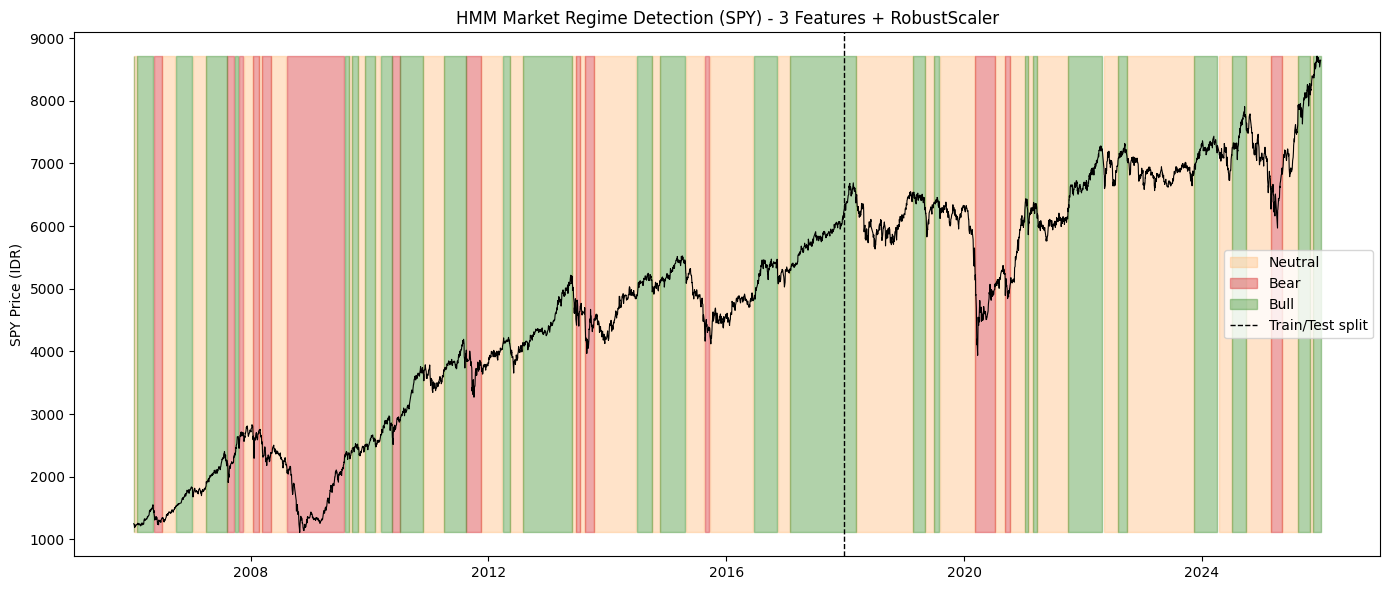

In [96]:
plt.figure(figsize=(14, 6))

plt.plot(features.index, close.loc[features.index], color='black', linewidth=0.8, zorder=3)

for state in range(3):
    mask = (smoothed_states == state)
    plt.fill_between(features.index,
                     close.loc[features.index].min(),
                     close.loc[features.index].max(),
                     where=mask, alpha=0.4, color=colors[state],
                     label=state_labels[state], zorder=1)

split_date = features.index[split]
plt.axvline(split_date, color='black', linestyle='--', linewidth=1, label='Train/Test split')
plt.legend()
plt.title('HMM Market Regime Detection (SPY) - 3 Features + RobustScaler')
plt.ylabel('SPY Price (IDR)')
plt.tight_layout()
plt.show()

In [97]:
for state in range(3):
    regime_returns = features['returns'].values[states == state]
    print(f"{state_labels[state]:8s} | Mean: {regime_returns.mean():.4f} | Std: {regime_returns.std():.4f} | Days: {len(regime_returns)}")

Neutral  | Mean: -0.0000 | Std: 0.0104 | Days: 2336
Bear     | Mean: -0.0005 | Std: 0.0236 | Days: 679
Bull     | Mean: 0.0013 | Std: 0.0076 | Days: 1826


In [98]:
# Check if test set regimes look sane vs train set
test_states = model.predict(scaler.transform(test_features))

print("Train regime distribution:")
for state in range(3):
    pct = (states[:split] == state).sum() / split * 100
    print(f"  {state_labels[state]:12s}: {pct:.1f}%")

print("\nTest regime distribution:")
for state in range(3):
    pct = (test_states == state).sum() / len(test_states) * 100
    print(f"  {state_labels[state]:12s}: {pct:.1f}%")

Train regime distribution:
  Neutral     : 38.4%
  Bear        : 18.5%
  Bull        : 43.0%

Test regime distribution:
  Neutral     : 63.0%
  Bear        : 7.3%
  Bull        : 29.7%


In [99]:
results = []

for n in range(2, 7):
    m = GaussianHMM(n_components=n, covariance_type="full", n_iter=200, random_state=42)
    m.fit(scaled_train)
    
    aic = m.aic(all_scaled)
    bic = m.bic(all_scaled)
    results.append((n, aic, bic))
    print(f"n={n} | AIC: {aic:.2f} | BIC: {bic:.2f} | Converged: {m.monitor_.converged}")

n=2 | AIC: 37805.09 | BIC: 38006.12 | Converged: True
n=3 | AIC: 31084.61 | BIC: 31408.85 | Converged: True
n=4 | AIC: 30019.43 | BIC: 30479.85 | Converged: True
n=5 | AIC: 28490.31 | BIC: 29099.89 | Converged: True
n=6 | AIC: 25562.39 | BIC: 26334.09 | Converged: True


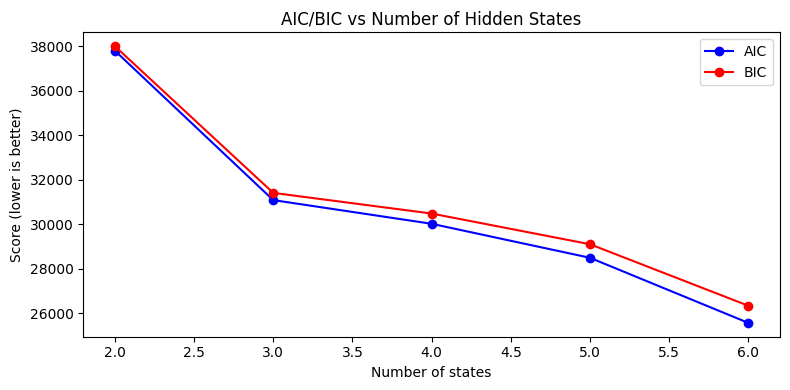

In [100]:
ns   = [r[0] for r in results]
aics = [r[1] for r in results]
bics = [r[2] for r in results]

plt.figure(figsize=(8, 4))
plt.plot(ns, aics, 'o-', label='AIC', color='blue')
plt.plot(ns, bics, 'o-', label='BIC', color='red')
plt.xlabel('Number of states')
plt.ylabel('Score (lower is better)')
plt.title('AIC/BIC vs Number of Hidden States')
plt.legend()
plt.tight_layout()
plt.show()

In [101]:
# State persistence — average days spent in each regime before switching
def compute_persistence(states, state_labels):
    persistence = {label: [] for label in state_labels.values()}
    
    current_state = states[0]
    count = 1
    
    for i in range(1, len(states)):
        if states[i] == current_state:
            count += 1
        else:
            persistence[state_labels[current_state]].append(count)
            current_state = states[i]
            count = 1
    
    # Don't forget the last run
    persistence[state_labels[current_state]].append(count)
    
    print("State Persistence (avg consecutive days per regime):")
    for label, runs in persistence.items():
        print(f"{label:12s} | Avg: {np.mean(runs):.1f} days | Max: {np.max(runs)} days | Transitions: {len(runs)}")

compute_persistence(states, state_labels)

State Persistence (avg consecutive days per regime):
Bear         | Avg: 45.3 days | Max: 221 days | Transitions: 15
Neutral      | Avg: 48.7 days | Max: 248 days | Transitions: 48
Bull         | Avg: 48.1 days | Max: 267 days | Transitions: 38


In [102]:
#log-likelihood on train vs test set
scaled_test = scaler.transform(test_features)

train_score = model.score(scaled_train) / len(scaled_train)
test_score = model.score(scaled_test) / len(scaled_test)

print(f"Train log-likelihood (per sample): {train_score:.4f}")
print(f"Test log-likelihood (per sample): {test_score:.4f}")
print(f"Difference: {abs(train_score - test_score):.4f}")

if abs(train_score - test_score) < 0.5:
    print("\nModel generalizes well - train and test scores are close")
elif test_score < train_score - 0.5:
    print("\nPossible overfitting — test score is significantly lower than train")

Train log-likelihood (per sample): -3.2879
Test log-likelihood (per sample): -3.0657
Difference: 0.2221

Model generalizes well - train and test scores are close


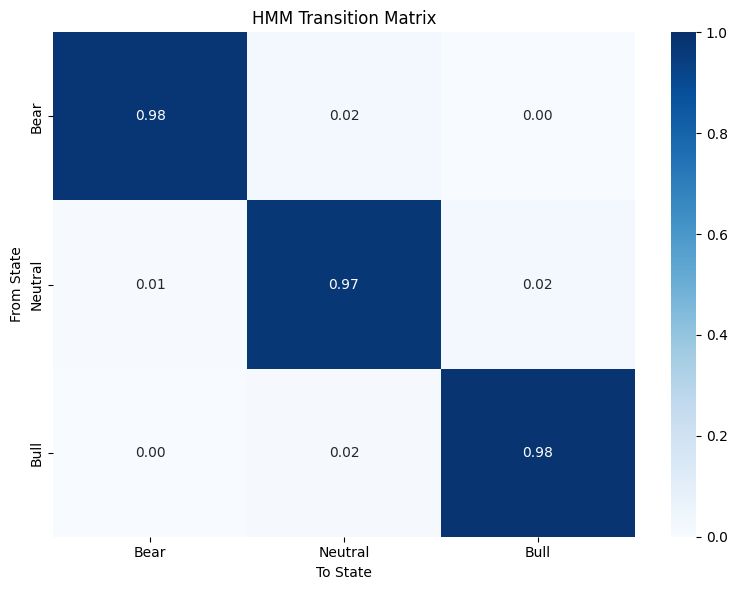

In [103]:
import seaborn as sns

# Get transition matrix and reorder by our state labels
# Build ordered label list from sorted_states
ordered_labels = [state_labels[sorted_states[i]] for i in range(3)]

# Reorder transition matrix rows/cols to match our labeling
transmat = model.transmat_

# Map sorted state indices to transition matrix
idx = [sorted_states[i] for i in range(3)]
reordered = transmat[np.ix_(idx, idx)]

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(reordered, 
            annot=True, 
            fmt='.2f',
            xticklabels=ordered_labels,
            yticklabels=ordered_labels,
            cmap='Blues',
            vmin=0, vmax=1)

plt.title('HMM Transition Matrix')
plt.ylabel('From State')
plt.xlabel('To State')
plt.tight_layout()
plt.show()

In [104]:
# Regime Prediction using forward algorithm + transition matrix
def predict_regime(model, recent_data, scaler, state_labels, sorted_states, k=1):
    # Scale the recent data
    scaled = scaler.transform(recent_data)

    # Forward algorithm - get current state probability distribution
    # model.predict_proba() returns P(state|observations) for each timestep
    state_probs = model.predict_proba(scaled)

    # Take the last timestep's probabilities as current state
    current_probs = state_probs[-1]

    # Project k steps ahead using the transition matrix
    future_probs = current_probs @ np.linalg.matrix_power(model.transmat_, k)

    #Map to labels
    predicted_state = np.argmax(future_probs)
    predicted_label = state_labels[predicted_state]

    print(f"Prediction {k} day(s) ahead:")
    print(f"Predicted regime: {predicted_label}")
    print(f"\nFull probability distribution:")
    for i in range(3):
        label = state_labels[sorted_states[i]]
        prob = future_probs[sorted_states[i]]
        print(f"  {label:.12s}: {prob:.4f} ({prob*100:.4f}%)")

    return predicted_label, future_probs

#Use last 60 days as recent data
recent_data = features.iloc[-60:]

#Predict 1, 5, 10 days ahead
for k in [1, 5, 10]:
    print(f"{'='*40}")
    predict_regime(model, recent_data, scaler, state_labels, sorted_states, k=k)
    print()

Prediction 1 day(s) ahead:
Predicted regime: Bull

Full probability distribution:
  Bear: 0.0033 (0.3348%)
  Neutral: 0.0155 (1.5489%)
  Bull: 0.9812 (98.1163%)

Prediction 5 day(s) ahead:
Predicted regime: Bull

Full probability distribution:
  Bear: 0.0165 (1.6464%)
  Neutral: 0.0709 (7.0894%)
  Bull: 0.9126 (91.2642%)

Prediction 10 day(s) ahead:
Predicted regime: Bull

Full probability distribution:
  Bear: 0.0321 (3.2126%)
  Neutral: 0.1281 (12.8060%)
  Bull: 0.8398 (83.9814%)



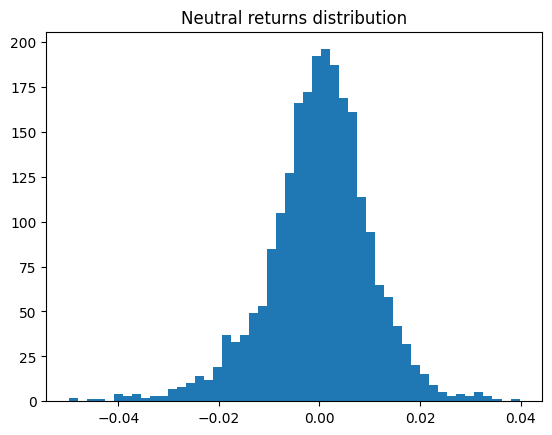

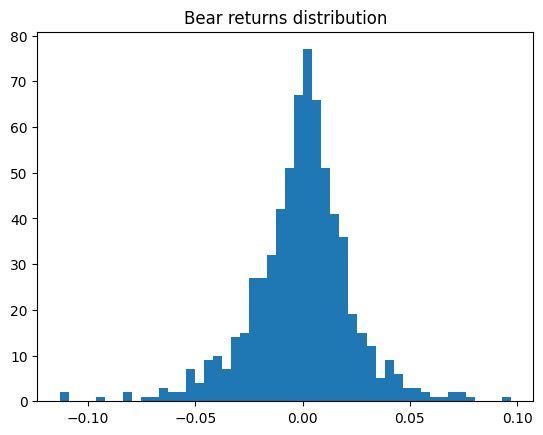

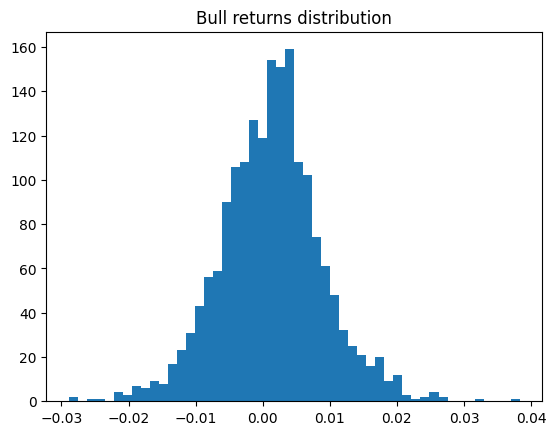

In [105]:
# Check if returns within each state look Gaussian
for state in range(3):
    regime_returns = features['returns'].values[states == state]
    plt.hist(regime_returns, bins=50)
    plt.title(f'{state_labels[state]} returns distribution')
    plt.show()

In [106]:
def walk_forward_hmm(features, n_splits=5, n_components=3):
    total = len(features)
    fold_size = total // (n_splits + 1)
    
    results = []
    for i in range(1, n_splits + 1):
        train = features.iloc[:fold_size * i]
        test = features.iloc[fold_size * i : fold_size * (i + 1)]
        
        scaler = RobustScaler()
        scaled_train = scaler.fit_transform(train)
        scaled_test = scaler.transform(test)
        
        model = GaussianHMM(n_components=n_components, 
                           covariance_type="full", 
                           n_iter=200, 
                           random_state=42)
        model.fit(scaled_train)
        
        train_score = model.score(scaled_train) / len(scaled_train)
        test_score = model.score(scaled_test) / len(scaled_test)
        
        print(f"Fold {i} | Train: {len(train)} days | "
              f"Test: {len(test)} days | "
              f"Train LL: {train_score:.4f} | "
              f"Test LL: {test_score:.4f} | "
              f"Gap: {abs(train_score-test_score):.4f}")
        results.append((train_score, test_score))
    
    avg_gap = np.mean([abs(r[0]-r[1]) for r in results])
    print(f"\nAverage gap across folds: {avg_gap:.4f}")
    return results

results = walk_forward_hmm(features, n_splits=5, n_components=3)

Fold 1 | Train: 806 days | Test: 806 days | Train LL: -2.5317 | Test LL: -2.7887 | Gap: 0.2571
Fold 2 | Train: 1612 days | Test: 806 days | Train LL: -3.4237 | Test LL: -3.0798 | Gap: 0.3439
Fold 3 | Train: 2418 days | Test: 806 days | Train LL: -3.2514 | Test LL: -2.0666 | Gap: 1.1848
Fold 4 | Train: 3224 days | Test: 806 days | Train LL: -3.2849 | Test LL: -3.5136 | Gap: 0.2287
Fold 5 | Train: 4030 days | Test: 806 days | Train LL: -3.4201 | Test LL: -2.7115 | Gap: 0.7086

Average gap across folds: 0.5446


In [107]:
# Get state-dependent parameters from the fitted model
decoded_states = states  # already computed from your predict() call

# Compute pseudo-residuals
pseudo_residuals = np.zeros(len(features))

for t in range(len(features)):
    s = decoded_states[t]
    
    # Get the mean and variance for this state
    # model.means_ shape: (n_states, n_features)
    # model.covars_ shape: (n_states, n_features, n_features) for full covariance
    mean = model.means_[s, 0]  # first feature (returns)
    std = np.sqrt(model.covars_[s, 0, 0])  # variance of first feature
    
    # Use the scaled version of returns (first features)
    obs = all_scaled[t, 0]

    # Step 1: compute percentile of this observation under its state distribution
    percentile = stats.norm.cdf(obs, loc=mean, scale=std)
    
    # Step 2: clip to avoid log(0) issues at the boundaries
    percentile = np.clip(percentile, 1e-6, 1 - 1e-6)
    
    # Step 3: convert percentile to standard normal quantile
    pseudo_residuals[t] = stats.norm.ppf(percentile)

print("Pseudo-residuals computed")
print(f"Mean: {pseudo_residuals.mean():.4f} (should be ~0)")
print(f"Std:  {pseudo_residuals.std():.4f} (should be ~1)")

Pseudo-residuals computed
Mean: -0.0127 (should be ~0)
Std:  0.9393 (should be ~1)


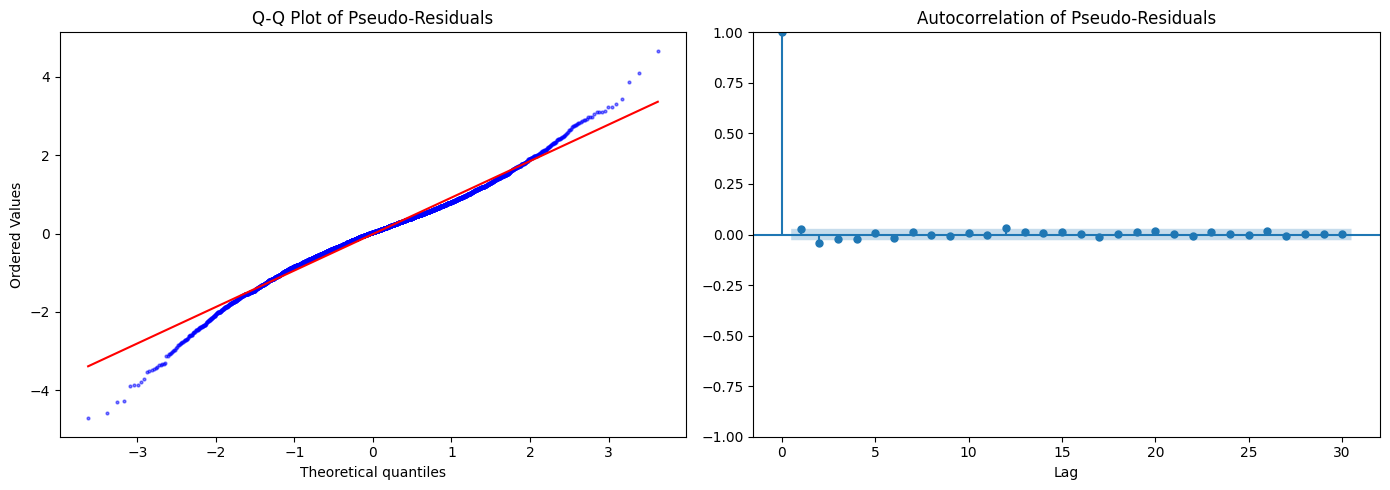

In [108]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Q-Q Plot
stats.probplot(pseudo_residuals, dist="norm", plot=axes[0])
axes[0].set_title("Q-Q Plot of Pseudo-Residuals")
axes[0].get_lines()[0].set(markersize=2, alpha=0.5)

# Autocorrelation Plot
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(pseudo_residuals, lags=30, ax=axes[1], alpha=0.05)
axes[1].set_title("Autocorrelation of Pseudo-Residuals")
axes[1].set_xlabel("Lag")

plt.tight_layout()
plt.show()

### Below this starts the Attempt at the Hierarchical HMM

In [109]:
# ============================================================
# HHMM (corrected) — Step 1: config + block grid + train/test boundary
# ============================================================
# Key fixes vs. the old version:
#   1. Fine models get REAL multivariate features (not returns-only)
#   2. There is a genuine train/test split — nothing is fit on test data
#   3. We will score held-out log-likelihood so the HHMM is *measurable*

block_size = 30
n_coarse = 3        # Bear / Neutral / Bull at the slow scale
n_fine = 2          # two sub-regimes within each coarse state

# Features the FINE models actually learn from (multi-vatriate, not returns only)
FINE_FEATURES = ['returns', 'volatility', 'drawdown']
# Features the COARSE models summarizes per block
COARSE_FEATURES = ['returns', 'volatility', 'long_momentum', 'drawdown']

# Block grid
n_total_blocks = len(features) // block_size
features_trimmed = features.iloc[:n_total_blocks * block_size]

# Train/Test boundary, expressed in whole blocks so a block never straddles it
n_train_blocks = (int(len(features) * 0.8)) // block_size
train_days = n_train_blocks * block_size

print(f"Block size:        {block_size} days")
print(f"Total blocks:      {n_total_blocks}")
print(f"Train blocks:      {n_train_blocks}  ({train_days} days)")
print(f"Test blocks:       {n_total_blocks - n_train_blocks}")
print(f"Fine features:     {FINE_FEATURES}")
print(f"Coarse features:   {COARSE_FEATURES}")

Block size:        30 days
Total blocks:      161
Train blocks:      129  (3870 days)
Test blocks:       32
Fine features:     ['returns', 'volatility', 'drawdown']
Coarse features:   ['returns', 'volatility', 'long_momentum', 'drawdown']


In [110]:
# ============================================================
# HHMM Step 2+3: coarse observations + coarse HMM (fit on TRAIN blocks only)
# ============================================================

# Each block -> one vector of its feature means
coarse_obs = np.zeros((n_total_blocks, len(COARSE_FEATURES)))
for i in range(n_total_blocks):
    block = features_trimmed.iloc[i * block_size : (i + 1) * block_size]
    coarse_obs[i] = [block[c].mean() for c in COARSE_FEATURES]

# Scale using TRAIN blocks only, then transform everything (no leak)
coarse_scaler = RobustScaler()
coarse_scaler.fit_transform(coarse_obs[:n_train_blocks])
coarse_scaled = coarse_scaler.transform(coarse_obs)

def fit_best_hmm(X, n_components, n_restarts=20):
    """Fit a GaussianHMM with multiple seeds, keep the best by train log-likelihood"""
    best, best_score = None, -np.inf
    for seed in range(n_restarts):
        cand = GaussianHMM(n_components=n_components, covariance_type='full', n_iter=200, random_state=seed)
        try:
            cand.fit(X)
            s = cand.score(X)
            if s > best_score:
                best_score, best = s, cand
        except Exception:
            continue
        return best, best_score
    
coarse_model, coarse_ll = fit_best_hmm(coarse_scaled[:n_train_blocks], n_coarse)
coarse_states = coarse_model.predict(coarse_scaled) # label ALL blocks

# Order coarse states Bear<Neutral<Bull by mean block return
coarse_state_means = [coarse_obs[coarse_states == s, 0].mean() for s in range(n_coarse)]
coarse_sorted = np.argsort(coarse_state_means)
coarse_labels = {coarse_sorted[0]: 'Bear',
                 coarse_sorted[1]: 'Neutral',
                 coarse_sorted[2]: 'Bull'}

print(f"Coarse train LL: {coarse_ll:.2f} | converged: {coarse_model.monitor_.converged}")
for s in range(n_coarse):
    pct = (coarse_states == s).sum() / n_total_blocks * 100
    print(f"  {coarse_labels[s]:8s}: {pct:5.1f}% ({(coarse_states == s).sum()} blocks)")

Coarse train LL: -605.53 | converged: True
  Neutral :  84.5% (136 blocks)
  Bear    :   5.6% (9 blocks)
  Bull    :   9.9% (16 blocks)


In [111]:
# ============================================================
# HHMM Step 4: fine-scale HMMs — MULTIVARIATE, fit on TRAIN days only
# ============================================================
# This is the big fix: each fine model now sees returns+volatility+drawdown,
# so its two sub-states are something it LEARNS, not a vol label we impose.

# Fine scaler fit on TRAIN days only
fine_scaler = RobustScaler()
fine_scaler.fit(features_trimmed.iloc[:train_days][FINE_FEATURES])
all_daily_fine = fine_scaler.transform(features_trimmed[FINE_FEATURES])

fine_models = {}
for cs in range(n_coarse):
    # blocks of this coarse state that fall in the TRAINING region
    train_blocks = [b for b in np.where(coarse_states == cs)[0] if b < n_train_blocks]
    if (len(train_blocks)) == 0:
        fine_models[cs] = None
        print(f"{coarse_labels[cs]:8s} | no train blocks - skipped")
        continue

    obs = np.vstack([all_daily_fine[b * block_size:(b + 1) * block_size] for b in train_blocks])
    fm, fll = fit_best_hmm(obs, n_fine)
    fine_models[cs] = fm
    print(f"{coarse_labels[cs]:8s} | fine LL: {fll:9.2f} | "
          f"converged: {fm.monitor_.converged} | train days: {len(obs)}")

Neutral  | fine LL:  -7475.12 | converged: True | train days: 3150
Bear     | fine LL:   -870.50 | converged: True | train days: 270
Bull     | fine LL:  -2269.77 | converged: True | train days: 450


In [112]:
# ============================================================
# HHMM Step 5: HONEST EVALUATION — held-out log-likelihood + AIC/BIC
# ============================================================
# We compare two models on the SAME held-out days and the SAME feature space
# (FINE_FEATURES), so the comparison is fair. The flat baseline is a single
# 3-state HMM over those features; the HHMM routes each test block through the
# fine model of its coarse state.

def count_params(model):
    """Free parameters of a full-covariance GaussianHMM"""
    n, nf = model.n_components, model.means_.shape[1]
    return (n - 1) + n*(n - 1) + n * nf + n*nf*(nf + 1)//2 # start + trans + means + covs

def aic_bic(total_ll, n_params, n_obs):
    return( 2*n_params - 2*total_ll,
           n_params*np.log(n_obs) - 2*total_ll)

# --- Flat, baseline on the SAME feature space, fit on train days only ---
flat_model, _ = fit_best_hmm(all_daily_fine[:train_days], n_coarse)

test_slice = all_daily_fine[train_days:]   # held-out days
flat_test_ll = flat_model.score(test_slice)
flat_params = count_params(flat_model)
flat_aic, flat_bic = aic_bic(flat_test_ll, flat_params, len(test_slice))

# --- HHMM held-out LL: each TEST block scored by its coarse state's fine model ---
hhmm_test_ll, hhmm_days = 0.0, 0
for b in range(n_train_blocks, n_total_blocks):
    fm = fine_models[coarse_states[b]]
    if fm is None:
        continue
    seg = all_daily_fine[b*block_size:(b+1)*block_size]
    hhmm_test_ll += fm.score(seg)
    hhmm_days += len(seg)

    hhmm_params = (count_params(coarse_model)
                   + sum(count_params(m) for m in fine_models.values() if m is not None))
    hhmm_aic, hhmm_bic = aic_bic(hhmm_test_ll, hhmm_params, hhmm_days)

print("Held-out comparison (same feature space, lower AIC/BIC = better):\n")
print(f"{'Model':12s} {'Test LL':>12s} {'Params':>8s} {'AIC':>12s} {'BIC':>12s}")
print(f"{'Flat 3-st':12s} {flat_test_ll:12.1f} {flat_params:8d} {flat_aic:12.1f} {flat_bic:12.1f}")
print(f"{'HHMM 3x2':12s} {hhmm_test_ll:12.1f} {hhmm_params:8d} {hhmm_aic:12.1f} {hhmm_bic:12.1f}")
print(f"\nHeld-out days scored: {hhmm_days}")
verdict = "HHMM wins" if hhmm_bic < flat_bic else "Flat model wins"
print(f"BIC verdict: {verdict} (Δ = {flat_bic - hhmm_bic:+.1f}, positive favors HHMM)")


Held-out comparison (same feature space, lower AIC/BIC = better):

Model             Test LL   Params          AIC          BIC
Flat 3-st         -1669.3       35       3408.6       3579.0
HHMM 3x2          -2090.0      113       4405.9       4955.9

Held-out days scored: 960
BIC verdict: Flat model wins (Δ = -1376.9, positive favors HHMM)


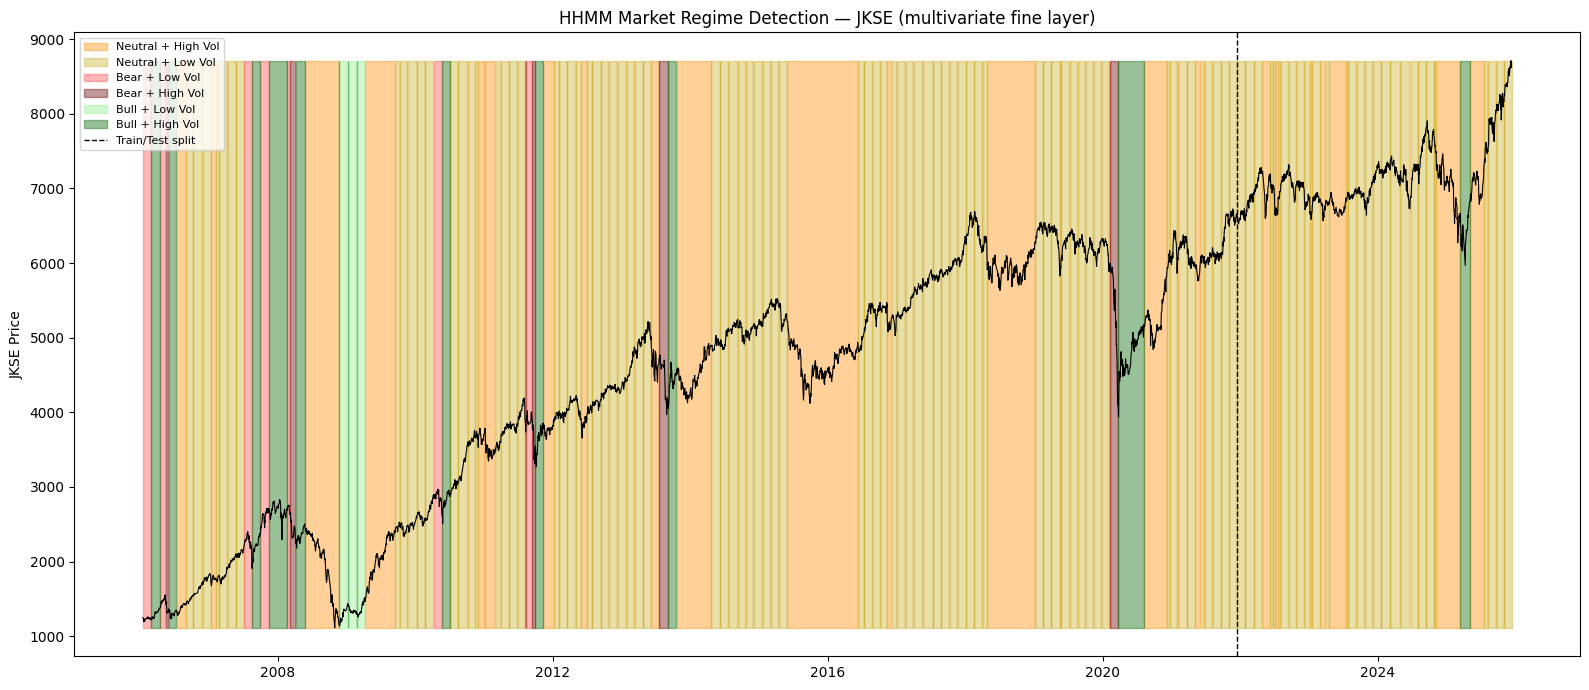


Regime statistics:
  Neutral  + High Vol | mean ret: -0.00016 | vol: 0.01224 | days: 1427
  Neutral  + Low Vol  | mean ret: +0.00073 | vol: 0.00770 | days: 2653
  Bear     + Low Vol  | mean ret: +0.00063 | vol: 0.01339 | days: 172
  Bear     + High Vol | mean ret: -0.00995 | vol: 0.01673 | days: 98
  Bull     + Low Vol  | mean ret: +0.00243 | vol: 0.01916 | days: 87
  Bull     + High Vol | mean ret: +0.00225 | vol: 0.02057 | days: 393


In [113]:
# ============================================================
# HHMM Step 6: decode every day, label fine states by learned vol, plot
# ============================================================

fine_states = np.zeros(len(features_trimmed), dtype = int)
for cs in range(n_coarse):
    fm = fine_models[cs]
    if fm is None:
        continue
    for b in np.where(coarse_states == cs)[0]:
        seg = all_daily_fine[b*block_size:(b+1)*block_size]
        fine_states[b*block_size:(b+1)*block_size] = fm.predict(seg)

# Label the two fine states High/Low Vol per coarse state (post-hoc, for readability)
fine_labels = {}
for cs in range(n_coarse):
    idx = []
    for b in np.where(coarse_states == cs)[0]:
        idx.extend(range(b*block_size, (b+1)*block_size))
    idx = np.array(idx)
    vols = [features_trimmed['volatility'].values[idx][fine_states[idx] == fs].mean() for fs in range(n_fine)]
    hv = int(np.argmax(vols))
    fine_labels[cs] = {hv: 'High Vol', 1 - hv: 'Low Vol'}

# Day-level coarse expansion
daily_coarse_states = np.repeat(coarse_states, block_size)[:len(features_trimmed)]

combined_colors = {
    ('Bear','High Vol'): "#680000", ('Bear','Low Vol'): "#FF4C4C",
    ('Neutral','High Vol'): "#FF8C00", ('Neutral','Low Vol'): "#C8B02A",
    ('Bull','High Vol'): "#006400", ('Bull','Low Vol'): "#90EE90",
}

close_trimmed = data['Close'].squeeze().loc[features_trimmed.index]
plt.figure(figsize=(16, 7))
plt.plot(features_trimmed.index, close_trimmed, color='black', linewidth=0.8, zorder=3)
for cs in range(n_coarse):
    for fs in range(n_fine):
        mask = (daily_coarse_states == cs) & (fine_states == fs)
        cname, fname = coarse_labels[cs], fine_labels[cs][fs]
        plt.fill_between(features_trimmed.index, close_trimmed.min(), close_trimmed.max(),
                         where=mask, alpha=0.4, color=combined_colors[(cname, fname)],
                         label=f"{cname} + {fname}", zorder=1)
plt.axvline(features_trimmed.index[train_days], color='black', linestyle='--',
            linewidth=1, label='Train/Test split')
plt.legend(loc='upper left', fontsize=8)
plt.title('HHMM Market Regime Detection — JKSE (multivariate fine layer)')
plt.ylabel('JKSE Price')
plt.tight_layout()
plt.show()

# Per-regime stats
print("\nRegime statistics:")
for cs in range(n_coarse):
    for fs in range(n_fine):
        mask = (daily_coarse_states == cs) & (fine_states == fs)
        if mask.sum() == 0:
            continue
        ret = features_trimmed['returns'].values[mask]
        vol = features_trimmed['volatility'].values[mask]
        print(f"  {coarse_labels[cs]:8s} + {fine_labels[cs][fs]:8s} | "
              f"mean ret: {ret.mean():+.5f} | vol: {vol.mean():.5f} | days: {mask.sum()}")  

In [115]:
# ============================================================
# WALK-FORWARD VALIDATION WITH PERIODIC RE-FITTING
# ============================================================


from sklearn.preprocessing import RobustScaler
from hmmlearn.hmm import GaussianHMM
import numpy as np

min_train_days = 252 * 3  # minimum 3 years to start
refit_every = 252          # refit every year
n_states = 3

all_wf_states = np.full(len(features), -1, dtype=int)  # -1 = not yet predicted
all_wf_labels = {}

fold = 1
cursor = min_train_days

while cursor < len(features):
    train = features.iloc[:cursor]
    test_end = min(cursor + refit_every, len(features))
    test = features.iloc[cursor:test_end]
    
    # Scale using only train data
    wf_scaler = RobustScaler()
    scaled_train = wf_scaler.fit_transform(train)
    scaled_test = wf_scaler.transform(test)
    
    # Fit with restarts
    best_model = None
    best_score = -np.inf
    for i in range(20):
        candidate = GaussianHMM(n_components=n_states, covariance_type="full",
                                n_iter=200, random_state=i)
        try:
            candidate.fit(scaled_train)
            score = candidate.score(scaled_train)
            if score > best_score:
                best_score = score
                best_model = candidate
        except:
            continue
    
    # Predict on test set
    test_states = best_model.predict(scaled_test)
    
    # Label states by mean return
    state_means = [train['returns'].values[best_model.predict(scaled_train) == s].mean() 
                   for s in range(n_states)]
    sorted_states = np.argsort(state_means)
    fold_labels = {
        sorted_states[0]: 'Bear',
        sorted_states[1]: 'Neutral',
        sorted_states[2]: 'Bull'
    }
    
    # Store predictions
    all_wf_states[cursor:test_end] = test_states
    all_wf_labels[fold] = fold_labels
    
    train_years = len(train) / 252
    per_sample_ll = best_score / len(train)
    print(f"Fold {fold:2d} | Train: {len(train):4d} days ({train_years:.1f}y) | "
      f"Test: {len(test):3d} days | "
      f"LL/sample: {per_sample_ll:.4f} | Converged: {best_model.monitor_.converged}")
    
    cursor = test_end
    fold += 1

print(f"\nTotal out-of-sample days predicted: {(all_wf_states != -1).sum()}")
print(f"Days not predicted (initial training period): {(all_wf_states == -1).sum()}")

Fold  1 | Train:  756 days (3.0y) | Test: 252 days | LL/sample: -2.4339 | Converged: True


Model is not converging.  Current: -3059.4884687901076 is not greater than -3059.4872237893255. Delta is -0.0012450007820916653


Fold  2 | Train: 1008 days (4.0y) | Test: 252 days | LL/sample: -2.7541 | Converged: True
Fold  3 | Train: 1260 days (5.0y) | Test: 252 days | LL/sample: -2.8040 | Converged: True
Fold  4 | Train: 1512 days (6.0y) | Test: 252 days | LL/sample: -3.0280 | Converged: True
Fold  5 | Train: 1764 days (7.0y) | Test: 252 days | LL/sample: -3.2594 | Converged: True
Fold  6 | Train: 2016 days (8.0y) | Test: 252 days | LL/sample: -3.1018 | Converged: True
Fold  7 | Train: 2268 days (9.0y) | Test: 252 days | LL/sample: -3.2694 | Converged: True
Fold  8 | Train: 2520 days (10.0y) | Test: 252 days | LL/sample: -3.2007 | Converged: True
Fold  9 | Train: 2772 days (11.0y) | Test: 252 days | LL/sample: -3.3584 | Converged: True
Fold 10 | Train: 3024 days (12.0y) | Test: 252 days | LL/sample: -3.2265 | Converged: True
Fold 11 | Train: 3276 days (13.0y) | Test: 252 days | LL/sample: -3.3048 | Converged: True
Fold 12 | Train: 3528 days (14.0y) | Test: 252 days | LL/sample: -3.3597 | Converged: True
Fold 

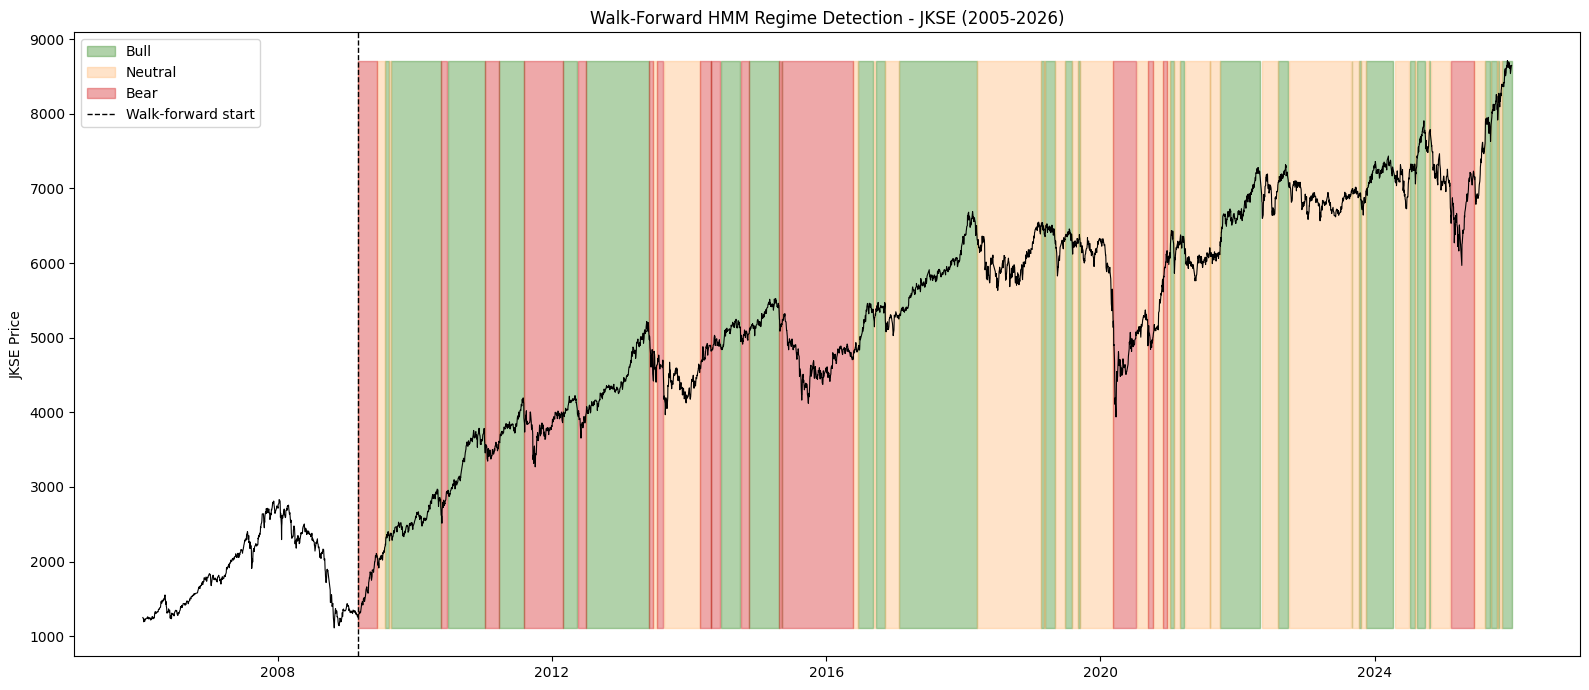

In [116]:
fig, ax = plt.subplots(figsize=(16, 7))

close_wf = data['Close'].squeeze().loc[features.index]
ax.plot(features.index, close_wf, color='black', linewidth=0.8, zorder=3)

colors = {'Bear': '#d62728', 'Neutral': '#ffbb78', 'Bull': '#3c902b'}

# Build a day-level label array using each fold's own mapping
wf_regime_labels = np.full(len(features), '', dtype=object)

cursor = min_train_days
for fold_num in range(1, len(all_wf_labels) + 1):
    test_end = min(cursor + refit_every, len(features))
    fold_labels = all_wf_labels[fold_num]
    
    for day_idx in range(cursor, test_end):
        state = all_wf_states[day_idx]
        wf_regime_labels[day_idx] = fold_labels.get(state, 'Unknown')
    
    cursor = test_end

# Plot each regime
for regime in ['Bull', 'Neutral', 'Bear']:
    mask = wf_regime_labels == regime
    ax.fill_between(features.index,
                    close_wf.min(),
                    close_wf.max(),
                    where=mask,
                    alpha=0.4,
                    color=colors[regime],
                    label=regime,
                    zorder=1)

ax.axvline(features.index[756], color='black', linestyle='--',
           linewidth=1, label='Walk-forward start')

ax.legend()
ax.set_title('Walk-Forward HMM Regime Detection - JKSE (2005-2026)')
ax.set_ylabel('JKSE Price')
plt.tight_layout()
plt.show()

In [ ]:
print("Walk-Forward Regime Statistics:")
for regime in ['Bull', 'Neutral', 'Bear']:
    mask = wf_regime_labels == regime
    ret = features['returns'].values[mask]
    if len(ret) > 0:
        print(f"{regime:8s} | Mean return: {ret.mean():.5f} | "
              f"Std: {ret.std():.5f} | Days: {mask.sum()}")

Walk-Forward Regime Statistics:
Bull     | Mean return: 0.00094 | Std: 0.00782 | Days: 1760
Neutral  | Mean return: 0.00000 | Std: 0.01014 | Days: 1424
Bear     | Mean return: 0.00031 | Std: 0.01583 | Days: 901


: 